In [1]:
import os, sys, json, shutil, subprocess, traceback
from pathlib import Path
from pprint import pprint

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

In [2]:
WORK_NAME = "M01_ds003768"

DATA_ROOT = Path("/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768")
RESULTS_ROOT = DATA_ROOT.parent / "rsCVR_Results"
WORK_ROOT = RESULTS_ROOT / WORK_NAME

INDEX_DIR = WORK_ROOT / "index"
LOG_DIR = WORK_ROOT / "logs"
QC_DIR = WORK_ROOT / "qc"
SPM_DIR = WORK_ROOT / "spm_preproc"
SUMMARY_DIR = WORK_ROOT / "summary"
MANIFEST_DIR = WORK_ROOT / "manifests"
RAPIDTIDE_DIR = WORK_ROOT / "rapidtide"

for d in [INDEX_DIR, LOG_DIR, QC_DIR, SPM_DIR, SUMMARY_DIR, MANIFEST_DIR, RAPIDTIDE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("WORK_ROOT    :", WORK_ROOT)
print("SUMMARY_DIR  :", SUMMARY_DIR)
print("RAPIDTIDE_DIR:", RAPIDTIDE_DIR)

WORK_ROOT    : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768
SUMMARY_DIR  : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/summary
RAPIDTIDE_DIR: /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide


In [3]:
# Defs
def load_json_safe(p):
    p = Path(p)
    with open(p, "r", encoding="utf-8") as f:
        return json.load(f)


def save_json(obj, p):
    p = Path(p)
    p.parent.mkdir(parents=True, exist_ok=True)
    with open(p, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def run_cmd(cmd, cwd=None, timeout=None):
    out = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        cwd=cwd,
        timeout=timeout,
        check=False
    )
    return {
        "cmd": cmd,
        "cwd": str(cwd) if cwd is not None else None,
        "returncode": out.returncode,
        "stdout": out.stdout,
        "stderr": out.stderr,
    }

# Defs for Visualisation
def load_3d_or_4d_first(path):
    img = nib.load(str(path))
    data = img.get_fdata(dtype=np.float32)

    if data.ndim == 4:
        data = data[..., 0]

    return img, data


def get_mid_slices(data):
    x, y, z = data.shape[:3]
    return data[x // 2, :, :], data[:, y // 2, :], data[:, :, z // 2]


def robust_limits(data, pmin=1, pmax=99):
    vals = data[np.isfinite(data)]
    if vals.size == 0:
        return None, None
    return np.percentile(vals, [pmin, pmax])


def plot_orth_map(path, title=None, cmap="gray", vmin=None, vmax=None):
    path = Path(path)
    img, data = load_3d_or_4d_first(path)

    if vmin is None or vmax is None:
        vmin0, vmax0 = robust_limits(data)
        if vmin is None:
            vmin = vmin0
        if vmax is None:
            vmax = vmax0

    sag, cor, axi = get_mid_slices(data)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    for ax, slc, name in zip(
        axes,
        [sag, cor, axi],
        ["Sagittal", "Coronal", "Axial"]
    ):
        im = ax.imshow(np.rot90(slc), cmap=cmap, vmin=vmin, vmax=vmax, origin="upper")
        ax.set_title(name)
        ax.axis("off")

    fig.suptitle(title if title else path.name)
    fig.tight_layout()
    plt.show()

    print("file :", path)
    print("shape:", img.shape)
    print("zooms:", img.header.get_zooms())
    print("vmin/vmax:", vmin, vmax)

In [4]:
# Load final summary
struct_summary_csv = SUMMARY_DIR / f"{WORK_NAME}_coreg_segment_norm_summary.csv"
assert struct_summary_csv.exists(), f"Missing structural summary: {struct_summary_csv}"

df_struct_summary = pd.read_csv(struct_summary_csv)

print("Loaded:", struct_summary_csv)
print("shape :", df_struct_summary.shape)
print(df_struct_summary.columns.tolist())
df_struct_summary.head()

Loaded: /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/summary/M01_ds003768_coreg_segment_norm_summary.csv
shape : (66, 21)
['subject', 'run', 'success', 'error', 'mean_bold', 'local_t1', 'coreg_t1', 'c1', 'c2', 'c3', 'y', 'iy', 'wc1', 'wc2', 'wc3', 'wr_t1', 'anat_dir', 'wmean_bold', 'wmean_exists', 'smoothed_filtered_bold', 'smoothing_success']


,subject,run,success,error,mean_bold,local_t1,coreg_t1,c1,c2,c3,...,iy,wc1,wc2,wc3,wr_t1,anat_dir,wmean_bold,wmean_exists,smoothed_filtered_bold,smoothing_success
0,sub-01,run-1,True,NaN,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
1,sub-01,run-2,True,NaN,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
2,sub-02,run-1,True,NaN,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
3,sub-02,run-2,True,NaN,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
4,sub-03,run-1,True,NaN,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True


In [5]:
# Required cols check
required_cols = [
    "subject",
    "run",
    "mean_bold",
    "c1",
    "c2",
    "c3",
    "y",
    "iy",
    "wr_t1",
    "wc1",
    "wc2",
    "wc3",
    "smoothed_filtered_bold",
]

missing_cols = [c for c in required_cols if c not in df_struct_summary.columns]

print("Missing columns:", missing_cols)
assert len(missing_cols) == 0, f"Missing columns in summary: {missing_cols}"

Missing columns: []


In [6]:
# Check Rapidtide exe
env_bin = Path(sys.executable).parent

RAPIDTIDE_EXE = shutil.which("rapidtide")

if RAPIDTIDE_EXE is None:
    candidate = env_bin / "rapidtide"
    if candidate.exists():
        RAPIDTIDE_EXE = str(candidate)

print("sys.executable:", sys.executable)
print("env_bin       :", env_bin)
print("PATH          :", os.environ.get("PATH", ""))
print("which rapidtide:", shutil.which("rapidtide"))
print("candidate exists:", (env_bin / "rapidtide").exists())
print("RAPIDTIDE_EXE :", RAPIDTIDE_EXE)
assert RAPIDTIDE_EXE is not None, "rapidtide executable not found"

version_res = run_cmd([RAPIDTIDE_EXE, "--version"])
print("returncode:", version_res["returncode"])
print("stdout:")
print(version_res["stdout"][:2000])
print("stderr:")
print(version_res["stderr"][:2000])

help_res = run_cmd([RAPIDTIDE_EXE, "--help"])
help_txt_path = LOG_DIR / f"{WORK_NAME}_rapidtide_help.txt"
help_txt_path.write_text(help_res["stdout"] + "\n\nSTDERR:\n" + help_res["stderr"]
                         , encoding="utf-8")
print("Saved rapidtide help:")
print(help_txt_path)
print(help_res["stdout"][:4000])

sys.executable: /home/bami/anaconda3/envs/JHA-spmCVR/bin/python
env_bin       : /home/bami/anaconda3/envs/JHA-spmCVR/bin
PATH          : /home/bami/anaconda3/bin:/home/bami/fsl/share/fsl/bin:/home/bami/fsl/share/fsl/bin:/home/bami/anaconda3/bin:/home/bami/anaconda3/condabin:/home/bami/anaconda3/condabin:/usr/local/cuda-11.2/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin
which rapidtide: None
candidate exists: True
RAPIDTIDE_EXE : /home/bami/anaconda3/envs/JHA-spmCVR/bin/rapidtide
returncode: 0
stdout:
rapidtide 3.1.9
Use --help option for detailed information on options.

stderr:

Saved rapidtide help:
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/logs/M01_ds003768_rapidtide_help.txt
usage: rapidtide [-h]
                 [--denoising | --delaymapping | --CVR | --globalpreselect]
                 [--venousrefine | --nirs] [--brainmask MASK[:VALSPEC]]
                 [--graymattermask MASK[:VALSPEC]]
            

In [7]:
## Build rapidtide manifest : 'smoothed_filtered_bold' as input
def find_motion_tsv_from_mean_bold(mean_bold_path, subject, run):
    run_dir = Path(mean_bold_path).parent
    candidates = [
        run_dir / f"{subject}_{run}_motion.tsv",
        run_dir / f"{subject}_{run}_motion.txt",
    ]

    candidates += sorted(run_dir.glob("*motion*.tsv"))
    candidates += sorted(run_dir.glob("rp_*.txt"))

    for p in candidates:
        if Path(p).exists():
            return str(p)

    return None


manifest_rows = []

for _, row in df_struct_summary.iterrows():
    subject = row["subject"]
    run = row["run"]

    input_bold = Path(row["smoothed_filtered_bold"])
    mean_bold = Path(row["mean_bold"])

    out_dir = RAPIDTIDE_DIR / subject / run / "sm4"
    out_dir.mkdir(parents=True, exist_ok=True)

    output_root = out_dir / f"{subject}_{run}_sm4_rapidtide"

    motion_tsv = find_motion_tsv_from_mean_bold(
        mean_bold_path=mean_bold,
        subject=subject,
        run=run
    )

    info = {
        "subject": subject,
        "run": run,
        "input_bold": str(input_bold),
        "input_exists": input_bold.exists(),
        "mean_bold": str(mean_bold),
        "mean_exists": mean_bold.exists(),
        "motion_tsv": motion_tsv,
        "motion_exists": Path(motion_tsv).exists() if motion_tsv is not None else False,
        "rapidtide_out_dir": str(out_dir),
        "rapidtide_output_root": str(output_root),
        "TR": None,
        "shape": None,
        "zooms": None,
        "n_volumes": None,
        "error": None,
    }

    try:
        if not input_bold.exists():
            raise FileNotFoundError(f"Missing input_bold: {input_bold}")

        img = nib.load(str(input_bold))
        info["shape"] = tuple(img.shape)
        info["zooms"] = tuple(img.header.get_zooms())

        if len(img.shape) == 4:
            info["n_volumes"] = int(img.shape[3])
            if len(img.header.get_zooms()) >= 4:
                info["TR"] = float(img.header.get_zooms()[3])
        else:
            raise ValueError(f"Expected 4D BOLD, got shape={img.shape}")

    except Exception as e:
        info["error"] = str(e)

    manifest_rows.append(info)

df_rapidtide_manifest = pd.DataFrame(manifest_rows)

print("Runs:", len(df_rapidtide_manifest))
print("\nInput exists:")
print(df_rapidtide_manifest["input_exists"].value_counts(dropna=False))

print("\nTR:")
print(df_rapidtide_manifest["TR"].value_counts(dropna=False))

print("\nErrors:")
display(df_rapidtide_manifest.loc[df_rapidtide_manifest["error"].notna()])

df_rapidtide_manifest

Runs: 66

Input exists:
input_exists
True    66
Name: count, dtype: int64

TR:
TR
0.0    66
Name: count, dtype: int64

Errors:


,subject,run,input_bold,input_exists,mean_bold,mean_exists,motion_tsv,motion_exists,rapidtide_out_dir,rapidtide_output_root,TR,shape,zooms,n_volumes,error


,subject,run,input_bold,input_exists,mean_bold,mean_exists,motion_tsv,motion_exists,rapidtide_out_dir,rapidtide_output_root,TR,shape,zooms,n_volumes,error
0,sub-01,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.0,"(80, 80, 35, 286)","(3.0, 3.0, 4.0, 0.0)",286,None
1,sub-01,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.0,"(80, 80, 35, 286)","(3.0, 3.0, 4.0, 0.0)",286,None
2,sub-02,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.0,"(80, 80, 35, 286)","(3.0, 2.9999998, 3.9999998, 0.0)",286,None
3,sub-02,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.0,"(80, 80, 35, 286)","(3.0, 2.9999998, 3.9999998, 0.0)",286,None
4,sub-03,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.0,"(80, 80, 35, 286)","(2.9999998, 3.0, 3.9999998, 0.0)",286,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,sub-31,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.0,"(80, 80, 35, 286)","(3.0, 3.0000002, 4.0, 0.0)",286,None
62,sub-32,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.0,"(80, 80, 35, 286)","(3.0, 3.0, 3.9999998, 0.0)",286,None
63,sub-32,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.0,"(80, 80, 35, 286)","(3.0, 3.0, 3.9999998, 0.0)",286,None
64,sub-33,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.0,"(80, 80, 35, 286)","(3.0, 3.0000002, 4.0, 0.0)",286,None


In [8]:
# Save rapidtide manifest
rapidtide_manifest_csv = MANIFEST_DIR / f"{WORK_NAME}_rapidtide_manifest_sm4.csv"
df_rapidtide_manifest.to_csv(rapidtide_manifest_csv, index=False)

print("Saved rapidtide manifest:")
print(rapidtide_manifest_csv)

Saved rapidtide manifest:
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/manifests/M01_ds003768_rapidtide_manifest_sm4.csv


In [9]:
# TR 없는 경우에만:
# Manual TR setting
MANUAL_TR = 2.1
print("MANUAL_TR:", MANUAL_TR)

def get_valid_tr_from_nifti(path, manual_tr=None):
    img = nib.load(str(path))
    zooms = img.header.get_zooms()
    tr = None
    if len(zooms) >= 4:
        tr = float(zooms[3])
    if tr is None or tr <= 0:
        if manual_tr is None:
            raise ValueError(f"Invalid TR in header: {tr}. Please provide manual_tr.")
        tr = float(manual_tr)
    return tr

tr_rows = []

for i, row in df_rapidtide_manifest.iterrows():
    input_bold = Path(row["input_bold"])
    tr = get_valid_tr_from_nifti(
        path=input_bold,
        manual_tr=MANUAL_TR
    )
    df_rapidtide_manifest.loc[i, "TR"] = tr
    tr_rows.append({
        "subject": row["subject"],
        "run": row["run"],
        "input_bold": str(input_bold),
        "TR": tr,
    })

df_tr_check = pd.DataFrame(tr_rows)
print(df_rapidtide_manifest["TR"].value_counts(dropna=False))
df_tr_check

MANUAL_TR: 2.1
TR
2.1    66
Name: count, dtype: int64


,subject,run,input_bold,TR
0,sub-01,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,2.1
1,sub-01,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,2.1
2,sub-02,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,2.1
3,sub-02,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,2.1
4,sub-03,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,2.1
...,...,...,...,...
61,sub-31,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,2.1
62,sub-32,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,2.1
63,sub-32,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,2.1
64,sub-33,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,2.1


In [10]:
# RE-save manifest
rapidtide_manifest_csv = MANIFEST_DIR / f"{WORK_NAME}_rapidtide_manifest_sm4.csv"
df_rapidtide_manifest.to_csv(rapidtide_manifest_csv, index=False)
print("Saved corrected rapidtide manifest:")
print(rapidtide_manifest_csv)

Saved corrected rapidtide manifest:
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/manifests/M01_ds003768_rapidtide_manifest_sm4.csv


In [11]:
p = Path(pilot_row["input_bold"])
img = nib.load(str(p))

print("input:", p)
print("shape:", img.shape)
print("zooms:", img.header.get_zooms())
print("pixdim:", img.header["pixdim"])

NameError: name 'pilot_row' is not defined

In [12]:
# Motionfile (tsv) check
# Check motion TSV format

motion_check_rows = []

for _, row in df_rapidtide_manifest.iterrows():
    motion_tsv = row["motion_tsv"]

    out = {
        "subject": row["subject"],
        "run": row["run"],
        "motion_tsv": motion_tsv,
        "exists": False,
        "shape": None,
        "columns": None,
        "n_rows": None,
        "n_volumes": row["n_volumes"],
        "row_match": False,
        "error": None,
    }

    try:
        if pd.isna(motion_tsv):
            raise FileNotFoundError("motion_tsv is NaN")

        p = Path(motion_tsv)
        out["exists"] = p.exists()

        if not p.exists():
            raise FileNotFoundError(f"Missing motion_tsv: {p}")

        df_mot = pd.read_csv(p, sep="\t")
        out["shape"] = df_mot.shape
        out["columns"] = ",".join(df_mot.columns.tolist())
        out["n_rows"] = len(df_mot)
        out["row_match"] = int(out["n_rows"]) == int(row["n_volumes"])

    except Exception as e:
        out["error"] = str(e)

    motion_check_rows.append(out)

df_motion_tsv_check = pd.DataFrame(motion_check_rows)

print("Exists:")
print(df_motion_tsv_check["exists"].value_counts(dropna=False))

print("\nRow match:")
print(df_motion_tsv_check["row_match"].value_counts(dropna=False))

display(df_motion_tsv_check.loc[~df_motion_tsv_check["row_match"]])
df_motion_tsv_check

Exists:
exists
True    66
Name: count, dtype: int64

Row match:
row_match
True    66
Name: count, dtype: int64


,subject,run,motion_tsv,exists,shape,columns,n_rows,n_volumes,row_match,error


,subject,run,motion_tsv,exists,shape,columns,n_rows,n_volumes,row_match,error
0,sub-01,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,"(286, 6)","x,y,z,pitch,roll,yaw",286,286,True,None
1,sub-01,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,"(286, 6)","x,y,z,pitch,roll,yaw",286,286,True,None
2,sub-02,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,"(286, 6)","x,y,z,pitch,roll,yaw",286,286,True,None
3,sub-02,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,"(286, 6)","x,y,z,pitch,roll,yaw",286,286,True,None
4,sub-03,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,"(286, 6)","x,y,z,pitch,roll,yaw",286,286,True,None
...,...,...,...,...,...,...,...,...,...,...
61,sub-31,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,"(286, 6)","x,y,z,pitch,roll,yaw",286,286,True,None
62,sub-32,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,"(286, 6)","x,y,z,pitch,roll,yaw",286,286,True,None
63,sub-32,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,"(286, 6)","x,y,z,pitch,roll,yaw",286,286,True,None
64,sub-33,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,"(286, 6)","x,y,z,pitch,roll,yaw",286,286,True,None


In [13]:
# option setting


RAPIDTIDE_INPUT_DIR = WORK_ROOT / "rapidtide_inputs"
RAPIDTIDE_INPUT_DIR.mkdir(parents=True, exist_ok=True)
print("RAPIDTIDE_INPUT_DIR:", RAPIDTIDE_INPUT_DIR)

MANUAL_TR = 2.1
MASK_THR = 0.5
OUTPUT_LEVEL = "normal"

REGRESSOR_SOURCE = "wholebrain"
REGRESSOR_STANDARDIZE = False   # 처음에는 z-scoring 하지 않음

print("MANUAL_TR             :", MANUAL_TR)
print("MASK_THR              :", MASK_THR)
print("OUTPUT_LEVEL          :", OUTPUT_LEVEL)
print("REGRESSOR_SOURCE      :", REGRESSOR_SOURCE)
print("REGRESSOR_STANDARDIZE :", REGRESSOR_STANDARDIZE)

RAPIDTIDE_INPUT_DIR: /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide_inputs
MANUAL_TR             : 2.1
MASK_THR              : 0.5
OUTPUT_LEVEL          : normal
REGRESSOR_SOURCE      : wholebrain
REGRESSOR_STANDARDIZE : False


In [14]:
# 6-cols motion correction txt creation
def make_rapidtide_motion_file(motion_tsv, out_path):
    motion_tsv = Path(motion_tsv)
    out_path = Path(out_path)

    df = pd.read_csv(motion_tsv, sep="\t")

    cols = ["x", "y", "z", "pitch", "roll", "yaw"]
    missing = [c for c in cols if c not in df.columns]

    if missing:
        raise ValueError(f"Missing motion columns {missing} in {motion_tsv}")

    arr = df[cols].astype(float).values
    np.savetxt(out_path, arr, fmt="%.8f")

    return str(out_path)

motion_rows = []

for _, row in tqdm(df_rapidtide_manifest.iterrows(), total=len(df_rapidtide_manifest), desc="Creating rapidtide motion files"):
    subject = row["subject"]
    run = row["run"]

    input_dir = RAPIDTIDE_INPUT_DIR / subject / run / "sm4"
    input_dir.mkdir(parents=True, exist_ok=True)

    motion_out = input_dir / f"{subject}_{run}_motion_6col.txt"

    out = {
        "subject": subject,
        "run": run,
        "motion_tsv": row["motion_tsv"],
        "motion_6col": str(motion_out),
        "motion_success": False,
        "n_rows": None,
        "n_cols": None,
        "error": None,
    }

    try:
        if pd.isna(row["motion_tsv"]) or not Path(row["motion_tsv"]).exists():
            raise FileNotFoundError(f"Missing motion_tsv: {row['motion_tsv']}")

        make_rapidtide_motion_file(row["motion_tsv"], motion_out)

        arr = np.loadtxt(motion_out)
        if arr.ndim == 1:
            arr = arr.reshape(1, -1)

        out["n_rows"] = arr.shape[0]
        out["n_cols"] = arr.shape[1]

        if arr.shape[0] != int(row["n_volumes"]):
            raise ValueError(f"Motion rows {arr.shape[0]} != n_volumes {row['n_volumes']}")

        if arr.shape[1] != 6:
            raise ValueError(f"Motion columns {arr.shape[1]} != 6")

        out["motion_success"] = True

    except Exception as e:
        out["error"] = str(e)

    motion_rows.append(out)

df_rapidtide_motion = pd.DataFrame(motion_rows)

print(df_rapidtide_motion["motion_success"].value_counts(dropna=False))
display(df_rapidtide_motion.loc[~df_rapidtide_motion["motion_success"]])
df_rapidtide_motion

Creating rapidtide motion files:   0%|          | 0/66 [00:00<?, ?it/s]

motion_success
True    66
Name: count, dtype: int64


,subject,run,motion_tsv,motion_6col,motion_success,n_rows,n_cols,error


,subject,run,motion_tsv,motion_6col,motion_success,n_rows,n_cols,error
0,sub-01,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,286,6,None
1,sub-01,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,286,6,None
2,sub-02,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,286,6,None
3,sub-02,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,286,6,None
4,sub-03,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,286,6,None
...,...,...,...,...,...,...,...,...
61,sub-31,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,286,6,None
62,sub-32,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,286,6,None
63,sub-32,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,286,6,None
64,sub-33,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,286,6,None


In [15]:
# Native MASK creation

def make_binary_mask_from_prob(prob_path, out_path, thr=0.2):
    prob_path = Path(prob_path)
    out_path = Path(out_path)

    img = nib.load(str(prob_path))
    data = img.get_fdata(dtype=np.float32)

    mask = (data >= thr).astype(np.uint8)

    out_img = nib.Nifti1Image(mask, img.affine, img.header)
    out_img.set_data_dtype(np.uint8)
    nib.save(out_img, str(out_path))

    return str(out_path)


def make_brainmask_from_tissues(c1_path, c2_path, c3_path, out_path, thr=0.2):
    c1_img = nib.load(str(c1_path))

    c1 = c1_img.get_fdata(dtype=np.float32)
    c2 = nib.load(str(c2_path)).get_fdata(dtype=np.float32)
    c3 = nib.load(str(c3_path)).get_fdata(dtype=np.float32)

    brain = ((c1 + c2 + c3) >= thr).astype(np.uint8)

    out_img = nib.Nifti1Image(brain, c1_img.affine, c1_img.header)
    out_img.set_data_dtype(np.uint8)
    nib.save(out_img, str(out_path))

    return str(out_path)

mask_rows = []
tag = str(MASK_THR).replace(".", "p")

for _, row in tqdm(df_struct_summary.iterrows(), total=len(df_struct_summary), desc="Creating native tissue masks"):
    subject = row["subject"]
    run = row["run"]

    run_dir = Path(row["mean_bold"]).parent
    mask_dir = run_dir / "masks"
    mask_dir.mkdir(parents=True, exist_ok=True)

    gm_mask = mask_dir / f"{subject}_{run}_gm_mask_thr{tag}.nii.gz"
    wm_mask = mask_dir / f"{subject}_{run}_wm_mask_thr{tag}.nii.gz"
    csf_mask = mask_dir / f"{subject}_{run}_csf_mask_thr{tag}.nii.gz"
    brain_mask = mask_dir / f"{subject}_{run}_brain_mask_tissue_thr{tag}.nii.gz"

    out = {
        "subject": subject,
        "run": run,
        "brain_mask": str(brain_mask),
        "gm_mask": str(gm_mask),
        "wm_mask": str(wm_mask),
        "csf_mask": str(csf_mask),
        "mask_success": False,
        "mask_error": None,
    }

    try:
        make_binary_mask_from_prob(row["c1"], gm_mask, thr=MASK_THR)
        make_binary_mask_from_prob(row["c2"], wm_mask, thr=MASK_THR)
        make_binary_mask_from_prob(row["c3"], csf_mask, thr=MASK_THR)
        make_brainmask_from_tissues(row["c1"], row["c2"], row["c3"], brain_mask, thr=MASK_THR)

        out["mask_success"] = all([
            brain_mask.exists(),
            gm_mask.exists(),
            wm_mask.exists(),
            csf_mask.exists(),
        ])

    except Exception as e:
        out["mask_error"] = str(e)

    mask_rows.append(out)

df_native_masks = pd.DataFrame(mask_rows)

print(df_native_masks["mask_success"].value_counts(dropna=False))
display(df_native_masks.loc[~df_native_masks["mask_success"]])
df_native_masks

Creating native tissue masks:   0%|          | 0/66 [00:00<?, ?it/s]

mask_success
True    66
Name: count, dtype: int64


,subject,run,brain_mask,gm_mask,wm_mask,csf_mask,mask_success,mask_error


,subject,run,brain_mask,gm_mask,wm_mask,csf_mask,mask_success,mask_error
0,sub-01,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,None
1,sub-01,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,None
2,sub-02,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,None
3,sub-02,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,None
4,sub-03,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,None
...,...,...,...,...,...,...,...,...
61,sub-31,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,None
62,sub-32,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,None
63,sub-32,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,None
64,sub-33,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,None


In [16]:
# Shape check (MASK)
mask_check_rows = []

for _, row in df_native_masks.iterrows():
    srow = df_struct_summary.query("subject == @row.subject and run == @row.run").iloc[0]
    ref_shape = tuple(nib.load(str(srow["mean_bold"])).shape)

    for key in ["brain_mask", "gm_mask", "wm_mask", "csf_mask"]:
        p = Path(row[key])

        out = {
            "subject": row["subject"],
            "run": row["run"],
            "mask_key": key,
            "path": str(p),
            "exists": p.exists(),
            "shape": None,
            "ref_shape": ref_shape,
            "same_shape_as_mean_bold": False,
            "nonzero_voxels": None,
            "error": None,
        }

        try:
            img = nib.load(str(p))
            data = img.get_fdata()

            out["shape"] = tuple(img.shape)
            out["same_shape_as_mean_bold"] = tuple(img.shape) == ref_shape
            out["nonzero_voxels"] = int(np.count_nonzero(data))

        except Exception as e:
            out["error"] = str(e)

        mask_check_rows.append(out)

df_native_mask_check = pd.DataFrame(mask_check_rows)

print("same_shape_as_mean_bold:")
print(df_native_mask_check["same_shape_as_mean_bold"].value_counts(dropna=False))

print("\nnonzero:")
print((df_native_mask_check["nonzero_voxels"] > 0).value_counts(dropna=False))

display(df_native_mask_check.loc[
    ~(df_native_mask_check["same_shape_as_mean_bold"] & (df_native_mask_check["nonzero_voxels"] > 0))
])

df_native_mask_check

same_shape_as_mean_bold:
same_shape_as_mean_bold
True    264
Name: count, dtype: int64

nonzero:
nonzero_voxels
True    264
Name: count, dtype: int64


,subject,run,mask_key,path,exists,shape,ref_shape,same_shape_as_mean_bold,nonzero_voxels,error


,subject,run,mask_key,path,exists,shape,ref_shape,same_shape_as_mean_bold,nonzero_voxels,error
0,sub-01,run-1,brain_mask,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,"(80, 80, 35)","(80, 80, 35)",True,41769,None
1,sub-01,run-1,gm_mask,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,"(80, 80, 35)","(80, 80, 35)",True,21408,None
2,sub-01,run-1,wm_mask,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,"(80, 80, 35)","(80, 80, 35)",True,11350,None
3,sub-01,run-1,csf_mask,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,"(80, 80, 35)","(80, 80, 35)",True,8468,None
4,sub-01,run-2,brain_mask,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,"(80, 80, 35)","(80, 80, 35)",True,41783,None
...,...,...,...,...,...,...,...,...,...,...
259,sub-33,run-1,csf_mask,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,"(80, 80, 35)","(80, 80, 35)",True,7268,None
260,sub-33,run-2,brain_mask,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,"(80, 80, 35)","(80, 80, 35)",True,42396,None
261,sub-33,run-2,gm_mask,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,"(80, 80, 35)","(80, 80, 35)",True,22538,None
262,sub-33,run-2,wm_mask,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,"(80, 80, 35)","(80, 80, 35)",True,12078,None


In [17]:
# Whole-brain mean regressor

def make_wholebrain_mean_regressor(bold_4d_path, brain_mask_path, out_path, standardize=False):
    bold_4d_path = Path(bold_4d_path)
    brain_mask_path = Path(brain_mask_path)
    out_path = Path(out_path)

    bold_img = nib.load(str(bold_4d_path))
    bold = bold_img.get_fdata(dtype=np.float32)

    mask_img = nib.load(str(brain_mask_path))
    mask = mask_img.get_fdata() > 0

    if bold.ndim != 4:
        raise ValueError(f"Expected 4D BOLD, got shape={bold.shape}")

    if bold.shape[:3] != mask.shape:
        raise ValueError(f"Shape mismatch: BOLD={bold.shape[:3]}, mask={mask.shape}")

    ts = bold[mask, :].mean(axis=0)

    if standardize:
        ts = ts - np.nanmean(ts)
        sd = np.nanstd(ts)
        if sd > 0:
            ts = ts / sd

    np.savetxt(out_path, ts, fmt="%.8f")
    return str(out_path)

# Attach masks first, temporarily, for regressor generation
df_reg_base = df_rapidtide_manifest.drop(
    columns=[c for c in ["brain_mask", "gm_mask", "wm_mask", "csf_mask"] if c in df_rapidtide_manifest.columns],
    errors="ignore"
).merge(
    df_native_masks[["subject", "run", "brain_mask", "gm_mask", "wm_mask", "csf_mask"]],
    on=["subject", "run"],
    how="left"
)

regressor_rows = []

for _, row in tqdm(df_reg_base.iterrows(), total=len(df_reg_base), desc="Creating whole-brain regressors"):
    subject = row["subject"]
    run = row["run"]

    input_dir = RAPIDTIDE_INPUT_DIR / subject / run / "sm4"
    input_dir.mkdir(parents=True, exist_ok=True)

    regressor_file = input_dir / f"{subject}_{run}_wholebrain_mean_regressor.txt"

    out = {
        "subject": subject,
        "run": run,
        "regressor_source": "wholebrain",
        "regressor_file": str(regressor_file),
        "regressor_success": False,
        "n_timepoints": None,
        "mean": None,
        "std": None,
        "error": None,
    }

    try:
        make_wholebrain_mean_regressor(
            bold_4d_path=row["input_bold"],
            brain_mask_path=row["brain_mask"],
            out_path=regressor_file,
            standardize=REGRESSOR_STANDARDIZE
        )

        ts = np.loadtxt(regressor_file)

        out["n_timepoints"] = len(ts)
        out["mean"] = float(np.mean(ts))
        out["std"] = float(np.std(ts))

        if len(ts) != int(row["n_volumes"]):
            raise ValueError(f"Regressor length {len(ts)} != n_volumes {row['n_volumes']}")

        if not np.isfinite(ts).all():
            raise ValueError("Regressor contains non-finite values")

        if np.std(ts) <= 0:
            raise ValueError("Regressor has zero variance")

        out["regressor_success"] = True

    except Exception as e:
        out["error"] = str(e)

    regressor_rows.append(out)

df_rapidtide_regressor = pd.DataFrame(regressor_rows)

print(df_rapidtide_regressor["regressor_success"].value_counts(dropna=False))
display(df_rapidtide_regressor.loc[~df_rapidtide_regressor["regressor_success"]])
df_rapidtide_regressor

Creating whole-brain regressors:   0%|          | 0/66 [00:00<?, ?it/s]

regressor_success
True    66
Name: count, dtype: int64


,subject,run,regressor_source,regressor_file,regressor_success,n_timepoints,mean,std,error


,subject,run,regressor_source,regressor_file,regressor_success,n_timepoints,mean,std,error
0,sub-01,run-1,wholebrain,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,286,-0.000432,2.953088,None
1,sub-01,run-2,wholebrain,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,286,-0.000744,2.132032,None
2,sub-02,run-1,wholebrain,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,286,0.001574,1.884818,None
3,sub-02,run-2,wholebrain,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,286,-0.001541,1.286594,None
4,sub-03,run-1,wholebrain,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,286,0.000845,2.877182,None
...,...,...,...,...,...,...,...,...,...
61,sub-31,run-2,wholebrain,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,286,-0.000323,2.308225,None
62,sub-32,run-1,wholebrain,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,286,0.000916,2.830532,None
63,sub-32,run-2,wholebrain,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,286,-0.000107,1.774767,None
64,sub-33,run-1,wholebrain,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,286,-0.000316,2.290562,None


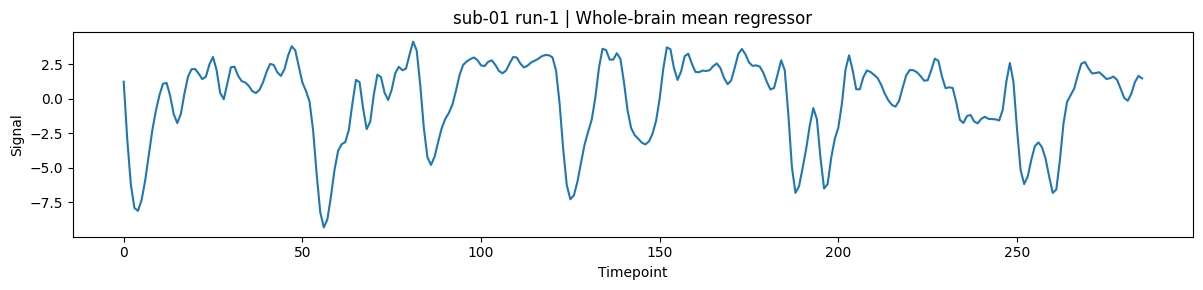

n_timepoints: 286
mean: -0.0004321451398601246
std : 2.9530877009672976


In [18]:
sample_reg = df_rapidtide_regressor.query("subject == 'sub-01' and run == 'run-1'").iloc[0]
ts = np.loadtxt(sample_reg["regressor_file"])

plt.figure(figsize=(12, 3))
plt.plot(ts)
plt.title(f"{sample_reg['subject']} {sample_reg['run']} | Whole-brain mean regressor")
plt.xlabel("Timepoint")
plt.ylabel("Signal")
plt.tight_layout()
plt.show()

print("n_timepoints:", len(ts))
print("mean:", np.mean(ts))
print("std :", np.std(ts))

In [19]:
# Avoid duplicated columns if this cell is re-run
drop_cols = [
    "brain_mask", "gm_mask", "wm_mask", "csf_mask",
    "motion_6col",
    "regressor_source", "regressor_file"
]

df_rapidtide_manifest = df_rapidtide_manifest.drop(
    columns=[c for c in drop_cols if c in df_rapidtide_manifest.columns],
    errors="ignore"
)

df_rapidtide_manifest = df_rapidtide_manifest.merge(
    df_native_masks[[
        "subject", "run",
        "brain_mask", "gm_mask", "wm_mask", "csf_mask"
    ]],
    on=["subject", "run"],
    how="left"
)

df_rapidtide_manifest = df_rapidtide_manifest.merge(
    df_rapidtide_motion[[
        "subject", "run", "motion_6col"
    ]],
    on=["subject", "run"],
    how="left"
)

df_rapidtide_manifest = df_rapidtide_manifest.merge(
    df_rapidtide_regressor[[
        "subject", "run", "regressor_source", "regressor_file"
    ]],
    on=["subject", "run"],
    how="left"
)


df_rapidtide_manifest["TR"] = df_rapidtide_manifest["TR"].fillna(MANUAL_TR)
df_rapidtide_manifest.loc[df_rapidtide_manifest["TR"] <= 0, "TR"] = MANUAL_TR
df_rapidtide_manifest[[
    "subject", "run", "input_bold", "TR",
    "brain_mask", "gm_mask", "wm_mask", "csf_mask",
    "motion_6col", "regressor_file"
]]

,subject,run,input_bold,TR,brain_mask,gm_mask,wm_mask,csf_mask,motion_6col,regressor_file
0,sub-01,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
1,sub-01,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
2,sub-02,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
3,sub-02,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
4,sub-03,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
...,...,...,...,...,...,...,...,...,...,...
61,sub-31,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
62,sub-32,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
63,sub-32,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
64,sub-33,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...


In [20]:
final_check_cols = [
    "input_bold",
    "brain_mask",
    "gm_mask",
    "wm_mask",
    "csf_mask",
    "motion_6col",
    "regressor_file",
]

for c in final_check_cols:
    df_rapidtide_manifest[f"{c}_exists"] = df_rapidtide_manifest[c].apply(
        lambda x: Path(x).exists() if pd.notna(x) else False
    )

exist_cols = [f"{c}_exists" for c in final_check_cols]

for c in exist_cols:
    print(f"\n{c}:")
    print(df_rapidtide_manifest[c].value_counts(dropna=False))

display(df_rapidtide_manifest.loc[
    ~df_rapidtide_manifest[exist_cols].all(axis=1),
    ["subject", "run"] + final_check_cols + exist_cols
])


input_bold_exists:
input_bold_exists
True    66
Name: count, dtype: int64

brain_mask_exists:
brain_mask_exists
True    66
Name: count, dtype: int64

gm_mask_exists:
gm_mask_exists
True    66
Name: count, dtype: int64

wm_mask_exists:
wm_mask_exists
True    66
Name: count, dtype: int64

csf_mask_exists:
csf_mask_exists
True    66
Name: count, dtype: int64

motion_6col_exists:
motion_6col_exists
True    66
Name: count, dtype: int64

regressor_file_exists:
regressor_file_exists
True    66
Name: count, dtype: int64


,subject,run,input_bold,brain_mask,gm_mask,wm_mask,csf_mask,motion_6col,regressor_file,input_bold_exists,brain_mask_exists,gm_mask_exists,wm_mask_exists,csf_mask_exists,motion_6col_exists,regressor_file_exists


In [21]:
rapidtide_manifest_csv = MANIFEST_DIR / f"{WORK_NAME}_rapidtide_manifest_sm4.csv"
df_rapidtide_manifest.to_csv(rapidtide_manifest_csv, index=False)
print("Saved:")
print(rapidtide_manifest_csv)

Saved:
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/manifests/M01_ds003768_rapidtide_manifest_sm4.csv


In [ ]:
## Rapidtide pilot :: initial options

In [22]:
# Initial rapidtide options
# Keep this empty for the first pilot.
# After checking output, we can add options if needed.

EXTRA_RAPIDTIDE_ARGS = []

print("EXTRA_RAPIDTIDE_ARGS:", EXTRA_RAPIDTIDE_ARGS)

EXTRA_RAPIDTIDE_ARGS: []


In [23]:
OUTPUT_LEVEL = "normal"

def build_rapidtide_cmd_from_row(row, extra_args=None):
    input_bold = str(Path(row["input_bold"]))
    output_root = str(Path(row["rapidtide_output_root"]))

    tr = row.get("TR", MANUAL_TR)
    if pd.isna(tr) or float(tr) <= 0:
        tr = MANUAL_TR
    tr = float(tr)

    cmd = [
        RAPIDTIDE_EXE,
        input_bold,
        output_root,

        "--CVR",
        "--datatstep", str(tr),

        "--regressor", str(Path(row["regressor_file"])),
        "--regressortstep", str(tr),

        "--brainmask", str(Path(row["brain_mask"])),
        "--graymattermask", str(Path(row["gm_mask"])),
        "--whitemattermask", str(Path(row["wm_mask"])),
        "--csfmask", str(Path(row["csf_mask"])),

        "--motionfile", str(Path(row["motion_6col"])),

        "--outputlevel", OUTPUT_LEVEL,
    ]

    if extra_args is not None:
        cmd += list(extra_args)

    return cmd

In [24]:
# Rapidtide pilot :: Single run
def run_rapidtide_one(row, extra_args=None, timeout=None, rerun=True):
    subject = row["subject"]
    run = row["run"]

    input_bold = Path(row["input_bold"])
    out_dir = Path(row["rapidtide_out_dir"])
    output_root = Path(row["rapidtide_output_root"])

    out_dir.mkdir(parents=True, exist_ok=True)

    log_stdout = out_dir / f"{subject}_{run}_rapidtide_stdout.txt"
    log_stderr = out_dir / f"{subject}_{run}_rapidtide_stderr.txt"
    log_cmd = out_dir / f"{subject}_{run}_rapidtide_cmd.json"

    result = {
        "subject": subject,
        "run": run,
        "input_bold": str(input_bold),
        "rapidtide_out_dir": str(out_dir),
        "rapidtide_output_root": str(output_root),
        "returncode": None,
        "success": False,
        "n_output_files": None,
        "stdout_log": str(log_stdout),
        "stderr_log": str(log_stderr),
        "cmd_json": str(log_cmd),
        "error": None,
    }

    try:
        if not input_bold.exists():
            raise FileNotFoundError(f"Missing input_bold: {input_bold}")

        existing_outputs = sorted(out_dir.glob("*"))
        if existing_outputs and not rerun:
            result["n_output_files"] = len(existing_outputs)
            result["success"] = True
            result["error"] = "Skipped: outputs already exist and rerun=False"
            return result

        cmd = build_rapidtide_cmd_from_row(
            row=row,
            extra_args=extra_args
        )

        save_json({"cmd": cmd}, log_cmd)

        res = run_cmd(cmd, cwd=out_dir, timeout=timeout)

        result["returncode"] = res["returncode"]

        log_stdout.write_text(res["stdout"], encoding="utf-8")
        log_stderr.write_text(res["stderr"], encoding="utf-8")

        if res["returncode"] != 0:
            raise RuntimeError(
                f"rapidtide failed with returncode={res['returncode']}\n"
                f"STDOUT tail:\n{res['stdout'][-3000:]}\n\n"
                f"STDERR tail:\n{res['stderr'][-3000:]}"
            )

        output_files = sorted(out_dir.glob("*"))
        result["n_output_files"] = len(output_files)
        result["success"] = len(output_files) > 0

        if not result["success"]:
            raise RuntimeError("rapidtide returned 0 but no output files were found.")

    except Exception:
        result["error"] = traceback.format_exc()

    return result

pilot_row = df_rapidtide_manifest.query("subject == 'sub-01' and run == 'run-1'").iloc[0]
pilot_cmd = build_rapidtide_cmd_from_row(pilot_row, extra_args=[])
print(" ".join(pilot_cmd))

/home/bami/anaconda3/envs/JHA-spmCVR/bin/rapidtide /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_run-1_preproc_bold_dt_filt_sm4.nii.gz /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide --CVR --datatstep 2.1 --regressor /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide_inputs/sub-01/run-1/sm4/sub-01_run-1_wholebrain_mean_regressor.txt --regressortstep 2.1 --brainmask /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/masks/sub-01_run-1_brain_mask_tissue_thr0p5.nii.gz --graymattermask /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/masks/sub-01_run-1_gm_mask_thr0p5.nii.gz --whitemattermask /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/masks/sub-01_run-1_wm_mask_thr0p5.nii.gz --csfmask /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_R

In [25]:
# pilot output 폴더 비우기
pilot_row = df_rapidtide_manifest.query("subject == 'sub-01' and run == 'run-1'").iloc[0]
pilot_out_dir = Path(pilot_row["rapidtide_out_dir"])

for p in pilot_out_dir.glob("*"):
    if p.is_file():
        p.unlink()
    elif p.is_dir():
        shutil.rmtree(p)

print("Cleaned output dir:", pilot_out_dir)
print("Regressor exists:", Path(pilot_row["regressor_file"]).exists())
print("Motion exists   :", Path(pilot_row["motion_6col"]).exists())

Cleaned output dir: /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4
Regressor exists: True
Motion exists   : True


In [26]:
pilot_cmd = build_rapidtide_cmd_from_row(pilot_row, extra_args=[])
print(" ".join(pilot_cmd))

/home/bami/anaconda3/envs/JHA-spmCVR/bin/rapidtide /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_run-1_preproc_bold_dt_filt_sm4.nii.gz /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide --CVR --datatstep 2.1 --regressor /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide_inputs/sub-01/run-1/sm4/sub-01_run-1_wholebrain_mean_regressor.txt --regressortstep 2.1 --brainmask /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/masks/sub-01_run-1_brain_mask_tissue_thr0p5.nii.gz --graymattermask /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/masks/sub-01_run-1_gm_mask_thr0p5.nii.gz --whitemattermask /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/masks/sub-01_run-1_wm_mask_thr0p5.nii.gz --csfmask /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_R

In [27]:
# Execute Pilot
pilot_result = run_rapidtide_one(
    pilot_row,
    extra_args=[],
    timeout=None,
    rerun=True
)

pilot_result

{'subject': 'sub-01',
 'run': 'run-1',
 'input_bold': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_run-1_preproc_bold_dt_filt_sm4.nii.gz',
 'rapidtide_out_dir': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4',
 'rapidtide_output_root': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide',
 'returncode': 0,
 'success': True,
 'n_output_files': 116,
 'stdout_log': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_rapidtide_stdout.txt',
 'stderr_log': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_rapidtide_stderr.txt',
 'cmd_json': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_rapidtide_cmd.json',
 'error': None}

In [28]:
# Check Pilot results:
print("success   :", pilot_result["success"])
print("returncode:", pilot_result["returncode"])
print("error     :", pilot_result["error"])
print("\nstdout log:", pilot_result["stdout_log"])
print("stderr log:", pilot_result["stderr_log"])
print("out dir   :", pilot_result["rapidtide_out_dir"])

if not pilot_result["success"]:
    print("STDOUT tail")
    print(Path(pilot_result["stdout_log"]).read_text(encoding="utf-8")[-3000:])

    print("\nSTDERR tail")
    print(Path(pilot_result["stderr_log"]).read_text(encoding="utf-8")[-3000:])

success   : True
returncode: 0
error     : None

stdout log: /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_rapidtide_stdout.txt
stderr log: /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_rapidtide_stderr.txt
out dir   : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4


In [29]:
# Pilot output inventory
def inventory_rapidtide_outputs(out_dir):
    out_dir = Path(out_dir)
    rows = []

    for p in sorted(out_dir.rglob("*")):
        if p.is_file():
            rows.append({
                "filename": p.name,
                "relative_path": str(p.relative_to(out_dir)),
                "path": str(p),
                "suffix": "".join(p.suffixes),
                "size_mb": p.stat().st_size / (1024 ** 2),
                "is_nifti": p.name.endswith(".nii") or p.name.endswith(".nii.gz"),
                "is_text": p.suffix.lower() in [".txt", ".tsv", ".csv", ".json"],
            })

    return pd.DataFrame(rows)


df_pilot_inventory = inventory_rapidtide_outputs(pilot_result["rapidtide_out_dir"])

print("n files:", len(df_pilot_inventory))
display(df_pilot_inventory.sort_values("relative_path"))

n files: 116


,filename,relative_path,path,suffix,size_mb,is_nifti,is_text
0,sub-01_run-1_rapidtide_cmd.json,sub-01_run-1_rapidtide_cmd.json,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,.json,0.001353,False,True
1,sub-01_run-1_rapidtide_stderr.txt,sub-01_run-1_rapidtide_stderr.txt,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,.txt,0.156058,False,True
2,sub-01_run-1_rapidtide_stdout.txt,sub-01_run-1_rapidtide_stdout.txt,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,.txt,0.001575,False,True
3,sub-01_run-1_sm4_rapidtide_DONE.txt,sub-01_run-1_sm4_rapidtide_DONE.txt,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,.txt,0.000000,False,True
4,sub-01_run-1_sm4_rapidtide_commandline.txt,sub-01_run-1_sm4_rapidtide_commandline.txt,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,.txt,0.001190,False,True
...,...,...,...,...,...,...,...
111,sub-01_run-1_sm4_rapidtide_desc-unfiltmean_map...,sub-01_run-1_sm4_rapidtide_desc-unfiltmean_map...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,.json,0.001687,False,True
112,sub-01_run-1_sm4_rapidtide_desc-unfiltmean_map...,sub-01_run-1_sm4_rapidtide_desc-unfiltmean_map...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,.nii.gz,0.508828,True,False
113,sub-01_run-1_sm4_rapidtide_formattedcommandlin...,sub-01_run-1_sm4_rapidtide_formattedcommandlin...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,.txt,0.001259,False,True
114,sub-01_run-1_sm4_rapidtide_log.txt,sub-01_run-1_sm4_rapidtide_log.txt,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,.txt,0.003410,False,True


In [30]:
# Inspect NIfTI outputs
df_pilot_nifti = df_pilot_inventory.loc[df_pilot_inventory["is_nifti"]].copy()

nifti_info_rows = []

for _, r in df_pilot_nifti.iterrows():
    p = Path(r["path"])

    info = {
        "filename": p.name,
        "relative_path": r["relative_path"],
        "path": str(p),
        "shape": None,
        "zooms": None,
        "min": None,
        "max": None,
        "mean": None,
        "std": None,
        "error": None,
    }

    try:
        img = nib.load(str(p))
        data = img.get_fdata(dtype=np.float32)
        finite = np.isfinite(data)

        info["shape"] = tuple(img.shape)
        info["zooms"] = tuple(img.header.get_zooms())

        if finite.any():
            vals = data[finite]
            info["min"] = float(vals.min())
            info["max"] = float(vals.max())
            info["mean"] = float(vals.mean())
            info["std"] = float(vals.std())

    except Exception as e:
        info["error"] = str(e)

    nifti_info_rows.append(info)

df_pilot_nifti_info = pd.DataFrame(nifti_info_rows)

print("NIfTI files:", len(df_pilot_nifti_info))
display(df_pilot_nifti_info.sort_values("filename"))

NIfTI files: 32


,filename,relative_path,path,shape,zooms,min,max,mean,std,error
0,sub-01_run-1_sm4_rapidtide_desc-CSF_mask.nii.gz,sub-01_run-1_sm4_rapidtide_desc-CSF_mask.nii.gz,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,"(80, 80, 35)","(3.0, 3.0, 4.0)",0.000000e+00,1.000000e+00,0.037804,1.907209e-01,None
1,sub-01_run-1_sm4_rapidtide_desc-CVRR2_map.nii.gz,sub-01_run-1_sm4_rapidtide_desc-CVRR2_map.nii.gz,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,"(80, 80, 35)","(3.0, 3.0, 4.0)",0.000000e+00,9.786296e-01,0.089297,2.234658e-01,None
2,sub-01_run-1_sm4_rapidtide_desc-CVRR_map.nii.gz,sub-01_run-1_sm4_rapidtide_desc-CVRR_map.nii.gz,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,"(80, 80, 35)","(3.0, 3.0, 4.0)",-9.892571e-01,9.890739e-01,-0.008896,2.986928e-01,None
3,sub-01_run-1_sm4_rapidtide_desc-CVRVariance_ma...,sub-01_run-1_sm4_rapidtide_desc-CVRVariance_ma...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,"(80, 80, 35)","(3.0, 3.0, 4.0)",-1.789504e+05,1.346478e+06,-1.353284,2.933448e+03,None
4,sub-01_run-1_sm4_rapidtide_desc-CVR_map.nii.gz,sub-01_run-1_sm4_rapidtide_desc-CVR_map.nii.gz,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,"(80, 80, 35)","(3.0, 3.0, 4.0)",-2.725988e+07,1.280579e+08,5074.826172,5.659226e+05,None
5,sub-01_run-1_sm4_rapidtide_desc-CoV_map.nii.gz,sub-01_run-1_sm4_rapidtide_desc-CoV_map.nii.gz,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,"(80, 80, 35)","(3.0, 3.0, 4.0)",0.000000e+00,1.871018e+07,693.966980,4.519362e+04,None
6,sub-01_run-1_sm4_rapidtide_desc-GM_mask.nii.gz,sub-01_run-1_sm4_rapidtide_desc-GM_mask.nii.gz,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,"(80, 80, 35)","(3.0, 3.0, 4.0)",0.000000e+00,1.000000e+00,0.095571,2.940026e-01,None
7,sub-01_run-1_sm4_rapidtide_desc-MTT_map.nii.gz,sub-01_run-1_sm4_rapidtide_desc-MTT_map.nii.gz,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,"(80, 80, 35)","(3.0, 3.0, 4.0)",0.000000e+00,1.015962e+02,0.862399,3.463380e+00,None
8,sub-01_run-1_sm4_rapidtide_desc-WM_mask.nii.gz,sub-01_run-1_sm4_rapidtide_desc-WM_mask.nii.gz,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,"(80, 80, 35)","(3.0, 3.0, 4.0)",0.000000e+00,1.000000e+00,0.050670,2.193222e-01,None
9,sub-01_run-1_sm4_rapidtide_desc-brainmask_mask...,sub-01_run-1_sm4_rapidtide_desc-brainmask_mask...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,"(80, 80, 35)","(3.0, 3.0, 4.0)",0.000000e+00,1.000000e+00,0.186469,3.894845e-01,None


In [31]:
# NIfTI maps of Pilot
df_pilot_nifti_info[["filename", "shape", "min", "max", "mean", "std", "error"]
                   ].sort_values("filename")

,filename,shape,min,max,mean,std,error
0,sub-01_run-1_sm4_rapidtide_desc-CSF_mask.nii.gz,"(80, 80, 35)",0.000000e+00,1.000000e+00,0.037804,1.907209e-01,None
1,sub-01_run-1_sm4_rapidtide_desc-CVRR2_map.nii.gz,"(80, 80, 35)",0.000000e+00,9.786296e-01,0.089297,2.234658e-01,None
2,sub-01_run-1_sm4_rapidtide_desc-CVRR_map.nii.gz,"(80, 80, 35)",-9.892571e-01,9.890739e-01,-0.008896,2.986928e-01,None
3,sub-01_run-1_sm4_rapidtide_desc-CVRVariance_ma...,"(80, 80, 35)",-1.789504e+05,1.346478e+06,-1.353284,2.933448e+03,None
4,sub-01_run-1_sm4_rapidtide_desc-CVR_map.nii.gz,"(80, 80, 35)",-2.725988e+07,1.280579e+08,5074.826172,5.659226e+05,None
5,sub-01_run-1_sm4_rapidtide_desc-CoV_map.nii.gz,"(80, 80, 35)",0.000000e+00,1.871018e+07,693.966980,4.519362e+04,None
6,sub-01_run-1_sm4_rapidtide_desc-GM_mask.nii.gz,"(80, 80, 35)",0.000000e+00,1.000000e+00,0.095571,2.940026e-01,None
7,sub-01_run-1_sm4_rapidtide_desc-MTT_map.nii.gz,"(80, 80, 35)",0.000000e+00,1.015962e+02,0.862399,3.463380e+00,None
8,sub-01_run-1_sm4_rapidtide_desc-WM_mask.nii.gz,"(80, 80, 35)",0.000000e+00,1.000000e+00,0.050670,2.193222e-01,None
9,sub-01_run-1_sm4_rapidtide_desc-brainmask_mask...,"(80, 80, 35)",0.000000e+00,1.000000e+00,0.186469,3.894845e-01,None


In [32]:
keywords = [
    "lag", "delay", "CVR", "cvr",
    "amp", "corr", "R2", "r2",
    "fit", "mask"
]

df_pilot_nifti_info["priority"] = df_pilot_nifti_info["filename"].apply(
    lambda x: any(k in x for k in keywords)
)

df_priority_maps = df_pilot_nifti_info.loc[
    df_pilot_nifti_info["priority"] &
    df_pilot_nifti_info["error"].isna()
].copy()

display(df_priority_maps[[
    "filename", "shape", "min", "max", "mean", "std"
]].sort_values("filename"))

,filename,shape,min,max,mean,std
0,sub-01_run-1_sm4_rapidtide_desc-CSF_mask.nii.gz,"(80, 80, 35)",0.000000e+00,1.000000e+00,0.037804,0.190721
1,sub-01_run-1_sm4_rapidtide_desc-CVRR2_map.nii.gz,"(80, 80, 35)",0.000000e+00,9.786296e-01,0.089297,0.223466
2,sub-01_run-1_sm4_rapidtide_desc-CVRR_map.nii.gz,"(80, 80, 35)",-9.892571e-01,9.890739e-01,-0.008896,0.298693
3,sub-01_run-1_sm4_rapidtide_desc-CVRVariance_ma...,"(80, 80, 35)",-1.789504e+05,1.346478e+06,-1.353284,2933.448486
4,sub-01_run-1_sm4_rapidtide_desc-CVR_map.nii.gz,"(80, 80, 35)",-2.725988e+07,1.280579e+08,5074.826172,565922.562500
6,sub-01_run-1_sm4_rapidtide_desc-GM_mask.nii.gz,"(80, 80, 35)",0.000000e+00,1.000000e+00,0.095571,0.294003
8,sub-01_run-1_sm4_rapidtide_desc-WM_mask.nii.gz,"(80, 80, 35)",0.000000e+00,1.000000e+00,0.050670,0.219322
9,sub-01_run-1_sm4_rapidtide_desc-brainmask_mask...,"(80, 80, 35)",0.000000e+00,1.000000e+00,0.186469,0.389484
10,sub-01_run-1_sm4_rapidtide_desc-confoundfilter...,"(80, 80, 35)",0.000000e+00,8.972691e-01,0.065726,0.153582
11,sub-01_run-1_sm4_rapidtide_desc-corrfit_mask.n...,"(80, 80, 35)",0.000000e+00,1.000000e+00,0.074893,0.263218


Selected maps: 17


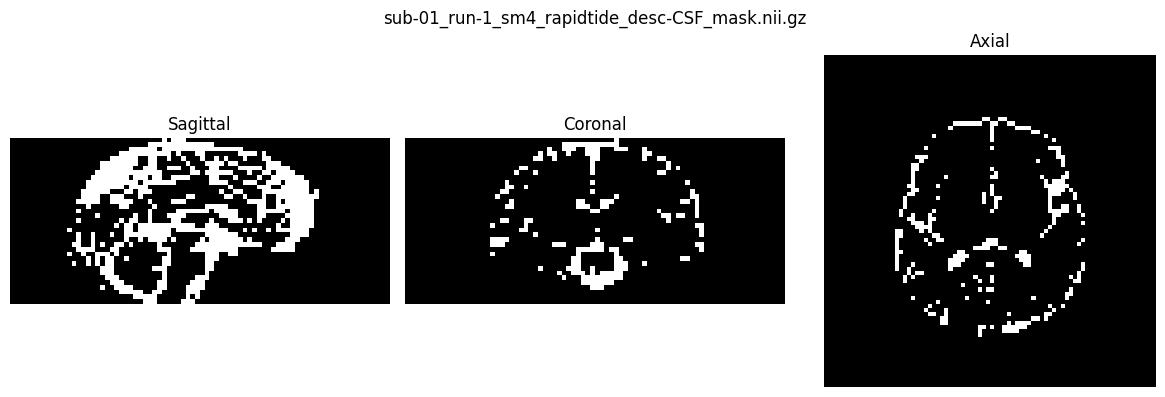

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-CSF_mask.nii.gz
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
vmin/vmax: 0.0 1.0


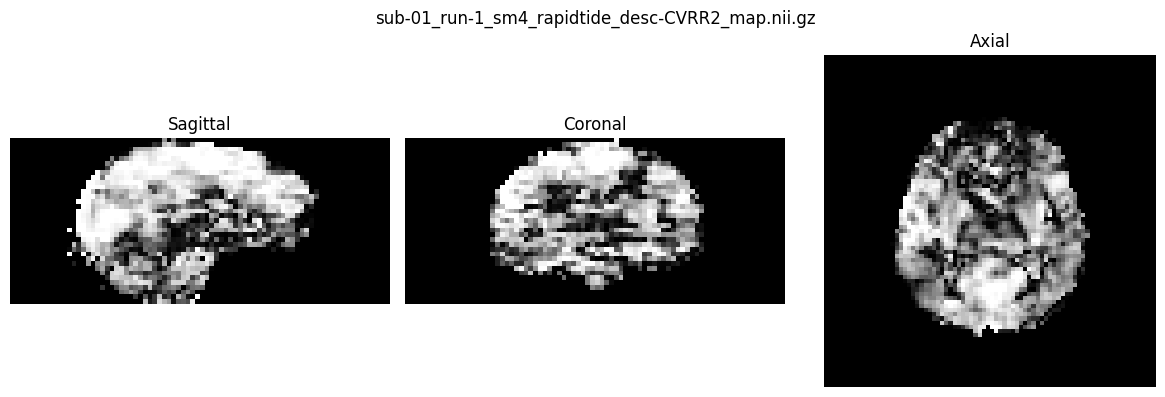

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-CVRR2_map.nii.gz
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
vmin/vmax: 0.0 0.8781862401962282


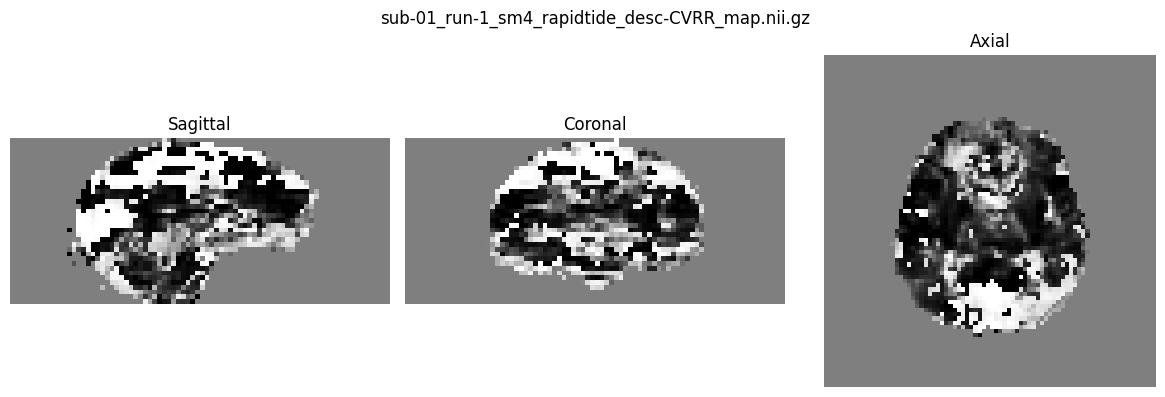

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-CVRR_map.nii.gz
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
vmin/vmax: -0.9096921372413636 0.9185054308176045


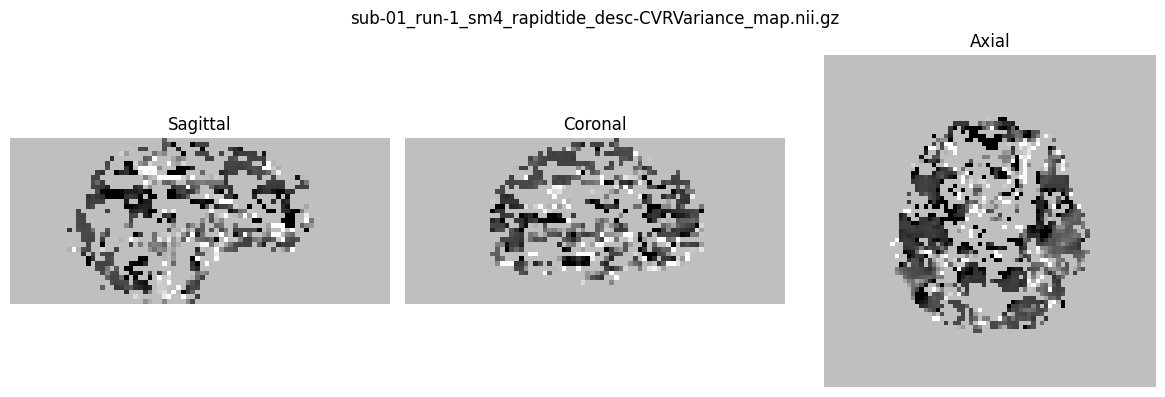

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-CVRVariance_map.nii.gz
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
vmin/vmax: -150.72850128173826 50.32429756164557


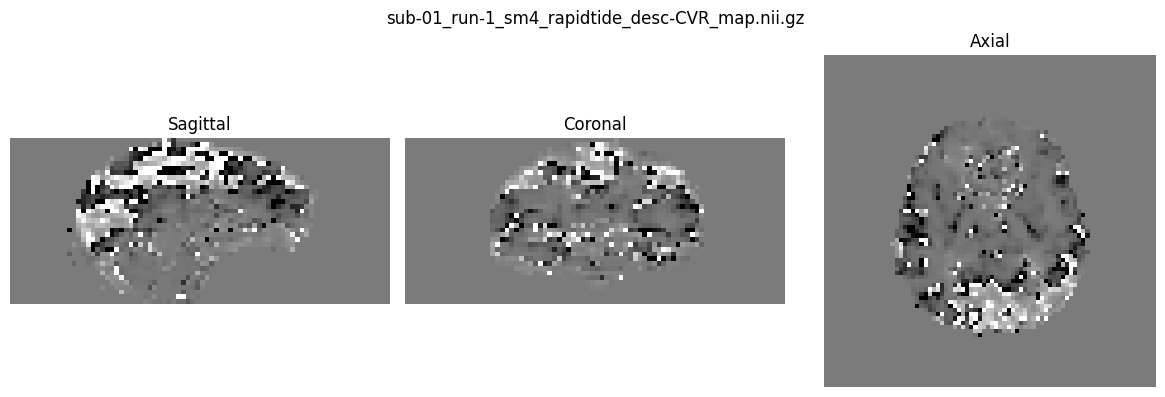

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-CVR_map.nii.gz
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
vmin/vmax: -146017.21453124998 156861.56562500008


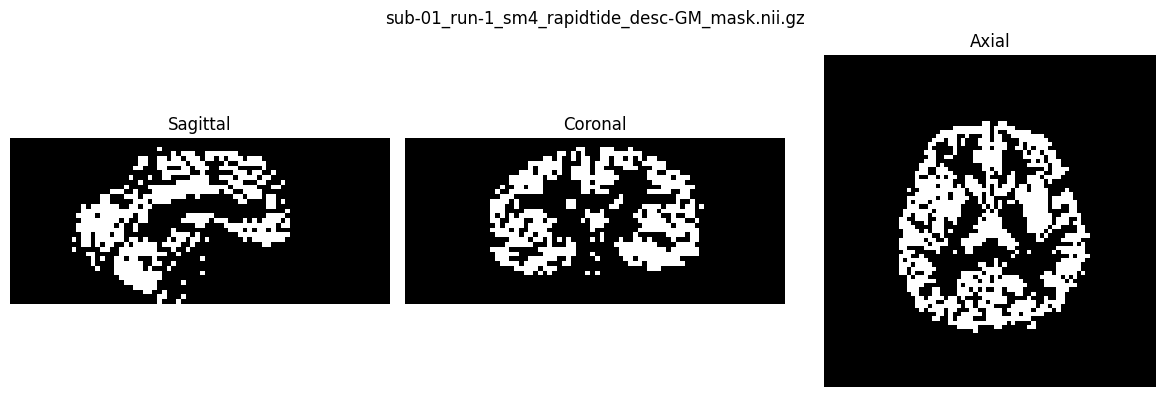

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-GM_mask.nii.gz
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
vmin/vmax: 0.0 1.0


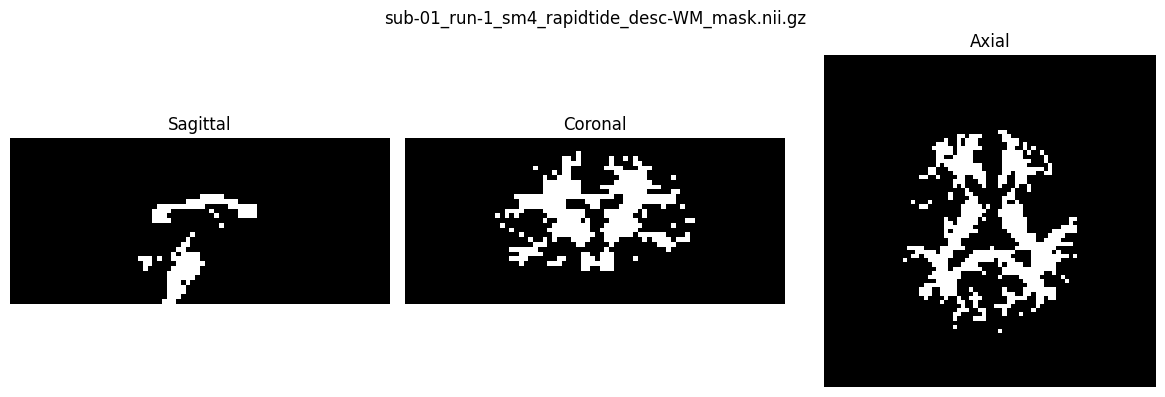

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-WM_mask.nii.gz
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
vmin/vmax: 0.0 1.0


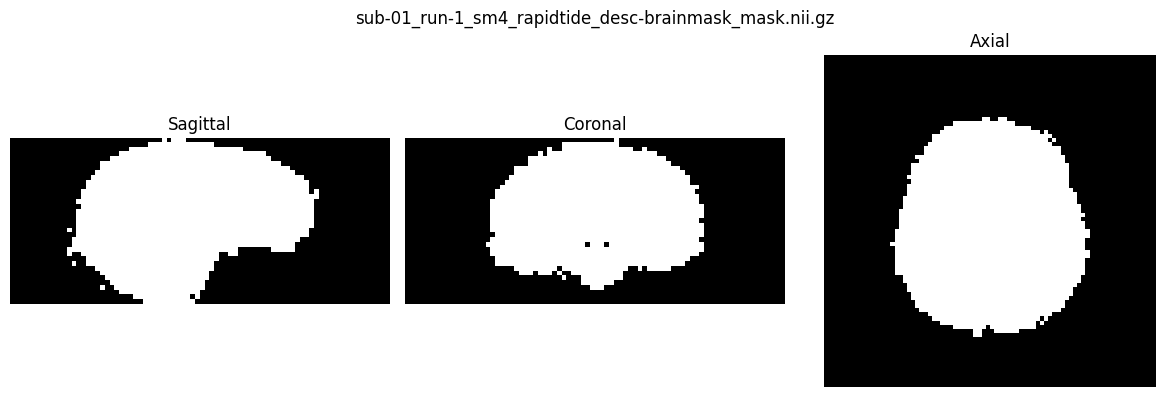

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-brainmask_mask.nii.gz
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
vmin/vmax: 0.0 1.0


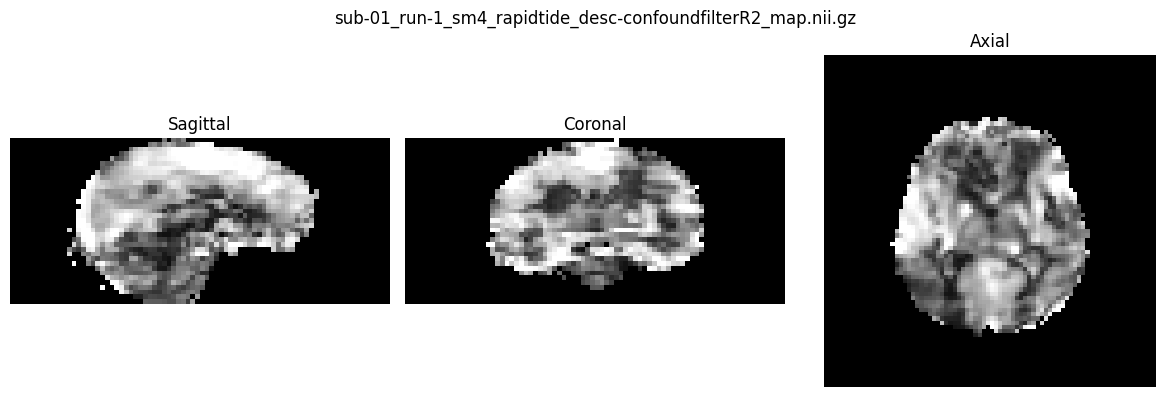

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-confoundfilterR2_map.nii.gz
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
vmin/vmax: 0.0 0.6111999213695526


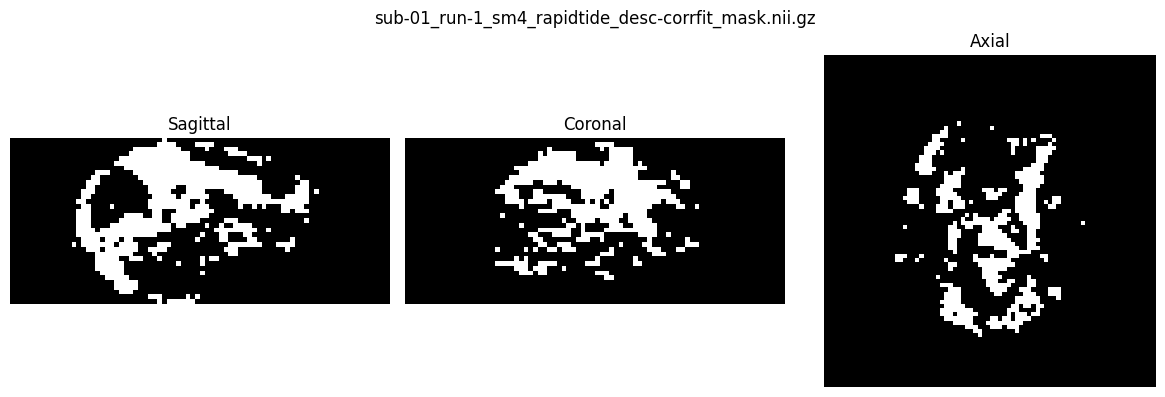

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-corrfit_mask.nii.gz
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
vmin/vmax: 0.0 1.0


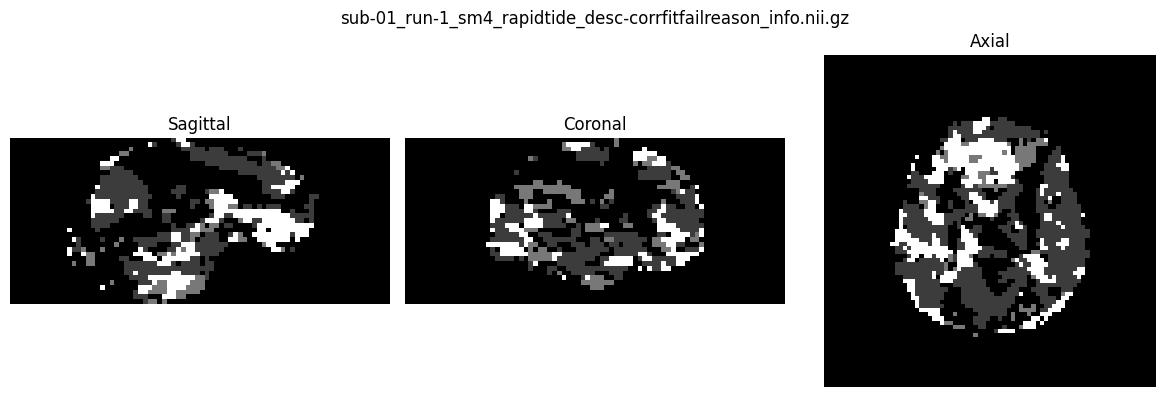

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-corrfitfailreason_info.nii.gz
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
vmin/vmax: 0.0 17413.0


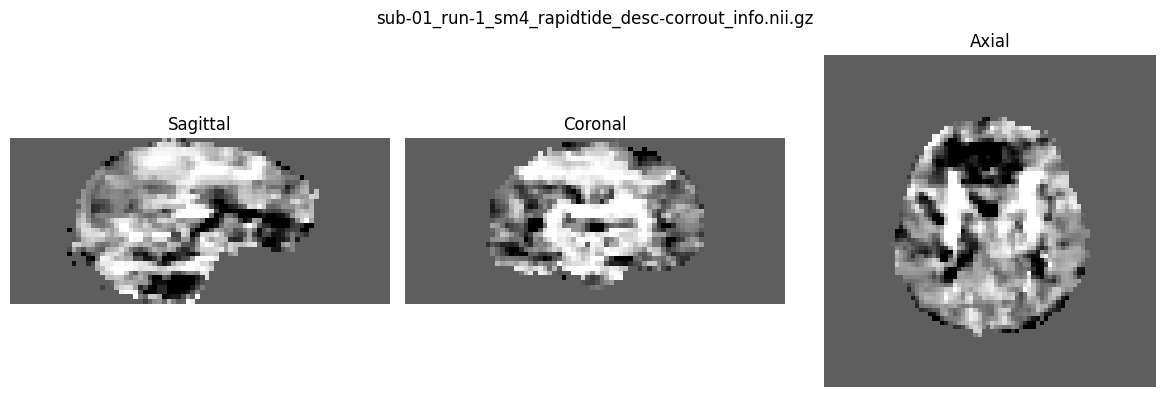

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-corrout_info.nii.gz
shape: (80, 80, 35, 59)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0), np.float32(0.42))
vmin/vmax: -0.46797121495008465 0.8049791443347933


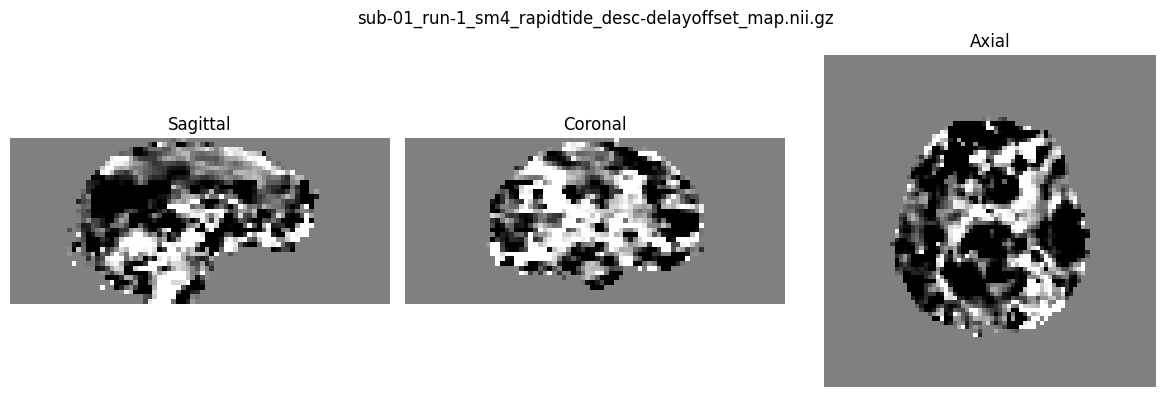

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-delayoffset_map.nii.gz
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
vmin/vmax: -4.980000019073486 4.980000019073486


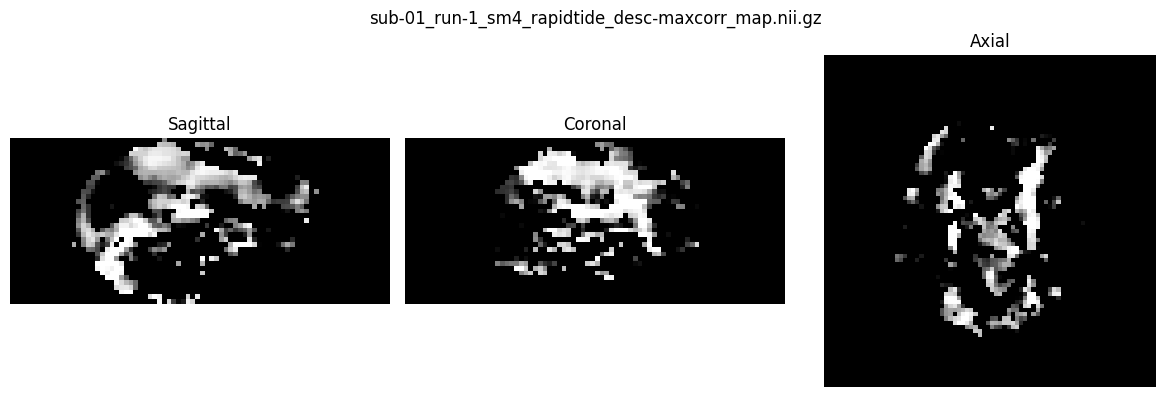

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-maxcorr_map.nii.gz
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
vmin/vmax: 0.0 0.8738249874115008


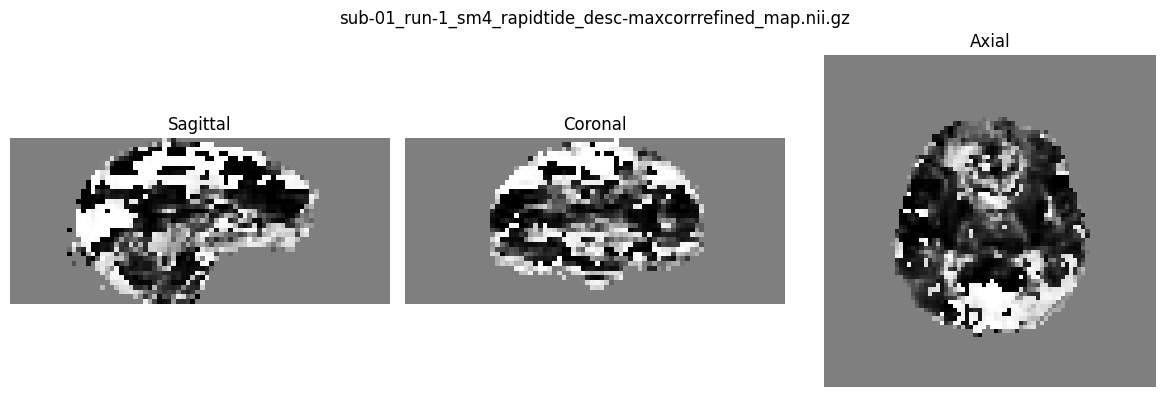

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-maxcorrrefined_map.nii.gz
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
vmin/vmax: -0.9100029593706132 0.9184295487403871


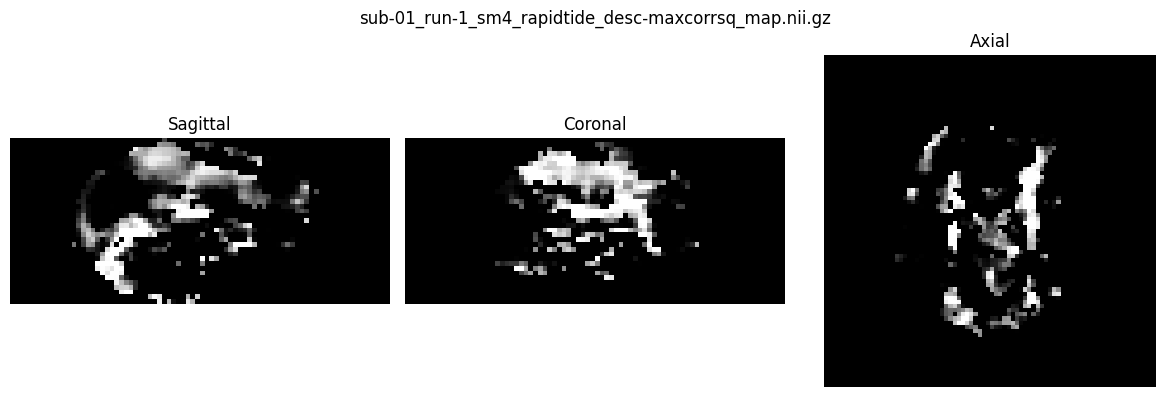

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-maxcorrsq_map.nii.gz
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
vmin/vmax: 0.0 0.7635700660944017


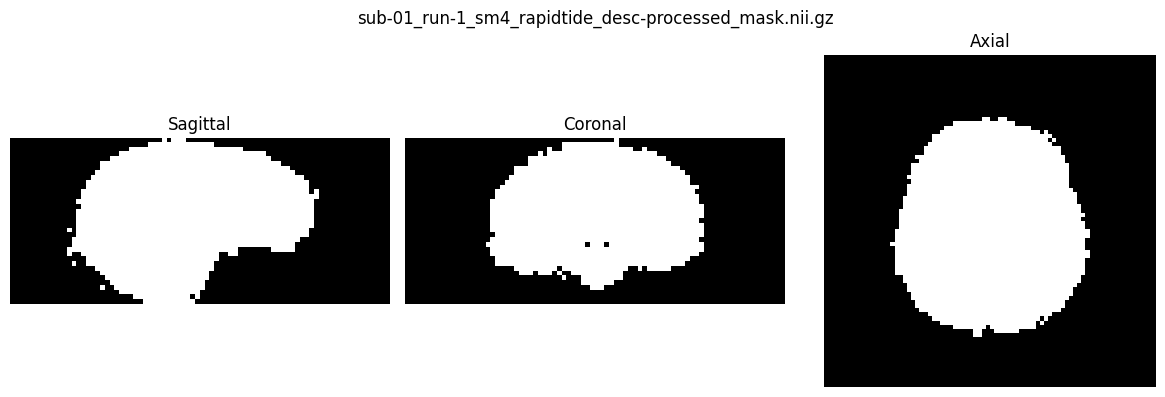

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-processed_mask.nii.gz
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
vmin/vmax: 0.0 1.0


In [33]:
selected_files = df_priority_maps["path"].tolist()

print("Selected maps:", len(selected_files))

for p in selected_files:
    plot_orth_map(
        p,
        title=Path(p).name,
        cmap="gray"
    )

In [ ]:
# Official final CVR map name from rapidtide documentation:

In [34]:
# XXX_desc-CVR_map.nii.gz

official_cvr_path = Path(str(pilot_row["rapidtide_output_root"]) + "_desc-CVR_map.nii.gz")

print("Official CVR map path:")
print(official_cvr_path)
print("exists:", official_cvr_path.exists())

if official_cvr_path.exists():
    img = nib.load(str(official_cvr_path))
    print("shape:", img.shape)
    print("zooms:", img.header.get_zooms())
else:
    print("Official CVR map not found. Check output inventory below.")

Official CVR map path:
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-CVR_map.nii.gz
exists: True
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))


In [56]:
def plot_orth_map_blackbg(path, mask_path=None, title=None,
                          cmap="OrRd_r", pct=75, signed=True):
    path = Path(path)
    img = nib.load(str(path))
    data = img.get_fdata(dtype=np.float32)

    if data.ndim == 4:
        data = data[..., 0]

    if mask_path is not None:
        mask = nib.load(str(mask_path)).get_fdata() > 0
        if mask.shape != data.shape:
            raise ValueError(f"Shape mismatch: data={data.shape}, mask={mask.shape}")
        data = np.where(mask, data, np.nan)

    vals = data[np.isfinite(data)]
    if vals.size == 0:
        raise ValueError(f"No finite values in {path}")

    if signed:
        vmax = np.nanpercentile(np.abs(vals), pct)
        vmin = -vmax
    else:
        vmin = 0
        vmax = np.nanpercentile(vals[vals > 0], pct) if np.any(vals > 0) else np.nanpercentile(vals, pct)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="black")

    x, y, z = data.shape[:3]
    sag = data[x // 2, :, :]
    cor = data[:, y // 2, :]
    axi = data[:, :, z // 2]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), facecolor="black")

    for ax, slc, name in zip(
        axes,
        [sag, cor, axi],
        ["Sagittal", "Coronal", "Axial"]
    ):
        ax.set_facecolor("black")
        im = ax.imshow(np.rot90(slc), cmap=cmap_obj, vmin=vmin, vmax=vmax)
        ax.set_title(name, color="white")
        ax.axis("off")

    fig.suptitle(title if title else path.name, color="white")
    fig.tight_layout()
    plt.show()

    print("file :", path)
    print("shape:", img.shape)
    print("zooms:", img.header.get_zooms())
    print("display range:", (vmin, vmax))

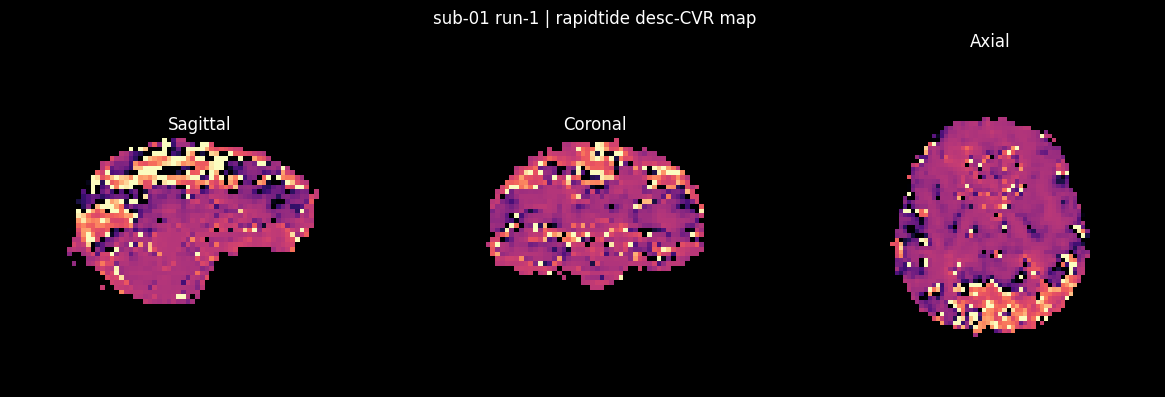

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-CVR_map.nii.gz
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
display range: (np.float32(-160825.86), np.float32(160825.86))


In [83]:
RSCVR_PATH = Path(str(pilot_row["rapidtide_output_root"]) + "_desc-CVR_map.nii.gz")
BRAIN_MASK_PATH = Path(pilot_row["brain_mask"])

plot_orth_map_blackbg(
    RSCVR_PATH,
    mask_path=BRAIN_MASK_PATH,
    title=f"{pilot_row['subject']} {pilot_row['run']} | rapidtide desc-CVR map",
    cmap="magma",
    pct=90,
    signed=True
)

refined lag: /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-maxtimerefined_map.nii.gz True
raw lag    : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-maxtime_map.nii.gz True


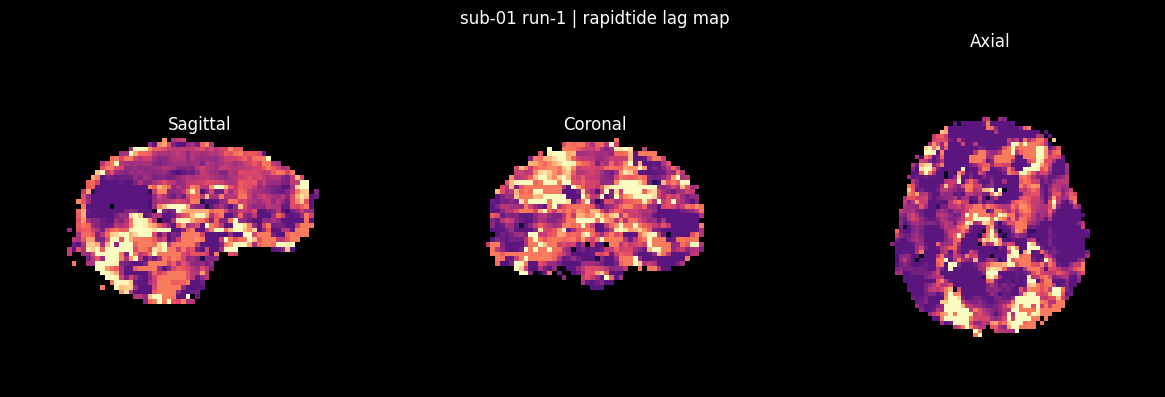

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/rapidtide/sub-01/run-1/sm4/sub-01_run-1_sm4_rapidtide_desc-maxtimerefined_map.nii.gz
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
display range: (np.float32(-11.0642605), np.float32(11.0642605))


In [79]:
# LAG_PATH = Path(str(pilot_row["rapidtide_output_root"]) + "_desc-maxtimerefined_map.nii.gz")
# LAG_PATH = Path(str(pilot_row["rapidtide_output_root"]) + "_desc-maxtime_map.nii.gz")

LAG_REFINED_PATH = Path(str(pilot_row["rapidtide_output_root"]) + "_desc-maxtimerefined_map.nii.gz")
LAG_RAW_PATH = Path(str(pilot_row["rapidtide_output_root"]) + "_desc-maxtime_map.nii.gz")

print("refined lag:", LAG_REFINED_PATH, LAG_REFINED_PATH.exists())
print("raw lag    :", LAG_RAW_PATH, LAG_RAW_PATH.exists())

if LAG_REFINED_PATH.exists():
    LAG_PATH = LAG_REFINED_PATH
elif LAG_RAW_PATH.exists():
    LAG_PATH = LAG_RAW_PATH
else:
    raise FileNotFoundError("No official rapidtide lag map found.")

plot_orth_map_blackbg(
    LAG_PATH,
    mask_path=Path(pilot_row["brain_mask"]),
    title=f"{pilot_row['subject']} {pilot_row['run']} | rapidtide lag map",
    cmap="magma",
    pct=90,
    signed=True
)

In [84]:
from nibabel.orientations import aff2axcodes

row = df_struct_summary.query("subject == 'sub-01' and run == 'run-1'").iloc[0]

check_paths = {
    "mean_bold": row["mean_bold"],
    "local_t1": row["local_t1"] if "local_t1" in row.index else None,
    "coreg_t1": row["coreg_t1"],
    "wr_t1": row["wr_t1"],
}

for name, p in check_paths.items():
    if p is None:
        print(f"\n{name}: not available")
        continue

    img = nib.load(str(p))

    print(f"\n===== {name} =====")
    print("path   :", p)
    print("shape  :", img.shape)
    print("zooms  :", img.header.get_zooms())
    print("axcode :", aff2axcodes(img.affine))
    print("affine :")
    print(img.affine)


===== mean_bold =====
path   : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/meansub-01_task-rest_run-1_bold_00001.nii
shape  : (80, 80, 35)
zooms  : (np.float32(3.0), np.float32(3.0), np.float32(4.0))
axcode : ('L', 'A', 'S')
affine :
[[-2.98749518e+00  2.47191787e-01 -1.56453252e-01  1.07450157e+02]
 [ 2.51555502e-01  2.98735881e+00 -1.48514748e-01 -1.17810684e+02]
 [-1.07667565e-01  1.20760977e-01  3.99417901e+00 -7.42012634e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

===== local_t1 =====
path   : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/sub-01_T1w.nii
shape  : (192, 256, 256)
zooms  : (np.float32(0.9999971), np.float32(1.0), np.float32(1.0))
axcode : ('R', 'A', 'S')
affine :
[[ 9.96174097e-01  7.99565315e-02 -3.51896286e-02 -1.05320801e+02]
 [-8.28622580e-02  9.92414474e-01 -9.08145905e-02 -9.99071350e+01]
 [ 2.76613235e-02  9.33833718e-02  9.95245874e-01 -

In [ ]:
# Full batch Exe
# RUN_FULL_BATCH = False
RUN_FULL_BATCH = True
print("RUN_FULL_BATCH:", RUN_FULL_BATCH)

batch_results = []

if RUN_FULL_BATCH:
    for _, r in tqdm(df_rapidtide_manifest.iterrows(), total=len(df_rapidtide_manifest), desc="rapidtide full batch"):
        res = run_rapidtide_one(
            r,
            extra_args=EXTRA_RAPIDTIDE_ARGS,
            timeout=None,
            rerun=True
        )
        batch_results.append(res)

    df_rapidtide_batch_summary = pd.DataFrame(batch_results)

else:
    print("RUN_FULL_BATCH=False. Full batch was not executed.")
    df_rapidtide_batch_summary = pd.DataFrame()

In [ ]:
if len(df_rapidtide_batch_summary) > 0:
    print(df_rapidtide_batch_summary["success"].value_counts(dropna=False))
    display(df_rapidtide_batch_summary.loc[~df_rapidtide_batch_summary["success"]])
    display(df_rapidtide_batch_summary.head())
else:
    print("No full batch summary yet.")

In [ ]:
# Batch exe summary

if len(df_rapidtide_batch_summary) > 0:
    rapidtide_batch_csv = SUMMARY_DIR / f"{WORK_NAME}_rapidtide_batch_summary_sm4.csv"
    rapidtide_batch_json = SUMMARY_DIR / f"{WORK_NAME}_rapidtide_batch_summary_sm4.json"

    df_rapidtide_batch_summary.to_csv(rapidtide_batch_csv, index=False)
    save_json(df_rapidtide_batch_summary.to_dict(orient="records"), rapidtide_batch_json)

    print("Saved:")
    print(rapidtide_batch_csv)
    print(rapidtide_batch_json)
else:
    print("No full batch summary to save.")

In [ ]:
# Full output inventory
inventory_rows = []

if len(df_rapidtide_batch_summary) > 0:
    for _, row in tqdm(df_rapidtide_batch_summary.iterrows(), total=len(df_rapidtide_batch_summary), desc="Inventory rapidtide outputs"):
        out_dir = Path(row["rapidtide_out_dir"])

        df_inv = inventory_rapidtide_outputs(out_dir)
        if len(df_inv) == 0:
            inventory_rows.append({
                "subject": row["subject"],
                "run": row["run"],
                "filename": None,
                "path": None,
                "suffix": None,
                "size_mb": None,
                "is_nifti": None,
                "is_text": None,
            })
        else:
            for _, inv in df_inv.iterrows():
                d = inv.to_dict()
                d.update({
                    "subject": row["subject"],
                    "run": row["run"],
                })
                inventory_rows.append(d)

    df_rapidtide_inventory = pd.DataFrame(inventory_rows)

    print("Inventory rows:", len(df_rapidtide_inventory))
    display(df_rapidtide_inventory.head())

else:
    df_rapidtide_inventory = pd.DataFrame()
    print("No batch inventory because full batch has not been run.")

In [ ]:
if len(df_rapidtide_inventory) > 0:
    rapidtide_inventory_csv = SUMMARY_DIR / f"{WORK_NAME}_rapidtide_output_inventory_sm4.csv"
    df_rapidtide_inventory.to_csv(rapidtide_inventory_csv, index=False)

    print("Saved:")
    print(rapidtide_inventory_csv)
else:
    print("No inventory to save.")

In [ ]:
# FINAL SUMMARY

print("===== M02-9 Rapidtide processing status =====")
print("Input BOLD column       : smoothed_filtered_bold")
print("Space                   : native BOLD space")
print("Smoothing               : FWHM [4,4,4]")
print("External motion regressors used in rapidtide:", False)
print("External probe used in rapidtide            :", False)
print("Extra rapidtide args    :", EXTRA_RAPIDTIDE_ARGS)

print("\nManifest runs:")
print(len(df_rapidtide_manifest))

print("\nInput exists:")
print(df_rapidtide_manifest["input_exists"].value_counts(dropna=False))

if len(df_rapidtide_batch_summary) > 0:
    print("\nBatch success:")
    print(df_rapidtide_batch_summary["success"].value_counts(dropna=False))
else:
    print("\nFull batch not yet executed.")